In [1]:
%matplotlib notebook
import numpy as np
import scipy as sp
from scipy import signal
import control
import matplotlib.pyplot as plt

# ПИД-регуляторы

До этого мы имели дело с настройкой регулятора, состоящего только из коэффициента усиления. Более общим понятием является ПИД-регулятор, который состоит из трёх слагаемых: пропорционального, интегрального и дифференциального. Отсюда название "ПИД". Передаточная функция регулятора имеет вид:
$$
K \cdot \left(1 + \frac{1}{T_i s} + T_d s\right)
$$

Для использования этих регуляторов существует много различных правил настройки. Мы здесь ограничимся рассмотрением только одного из них.

Примечание: в разной литературе коэффициенты в регуляторах пишут по-разному, поэтому правила настройки применять следует осторожно.

# Метод настройки Зиглера-Николса
Сперва рассматриваем регулятор, состоящий просто из коэффициента усиления $K$. Находим значение $K = K_u$, при котором система теряет устойчивость. На переходной функции обычно выглядит так:

<IPython.core.display.Javascript object>


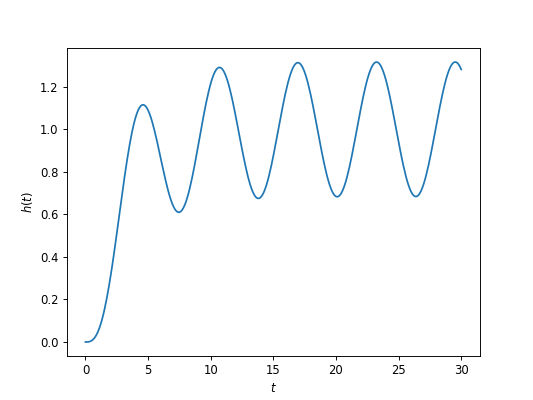

In [2]:
w = control.tf(1, [1, 1e-6, 1]) * control.tf(1, [3, 1])
t = np.linspace(0, 30, 300)
_, x = control.step_response(w, T=t)
plt.plot(t, x)
plt.xlabel('$t$')
plt.ylabel('$h(t)$')
pass

Далее, зафиксировав этот коэффициент усиления $K_u$ и период незатухающих колебаний $T_u$, выбираем какой-либо вариант коэффициентов из таблицы:

| $K$    | $T_i$ | $T_d$ |
| :---: | :---: | :---: |
| $0.5 K_u$  | - | - |
| $0.45 K_u$ | $T_u / 1.2$ | - |
| $0.8 K_u$ | - | $T_u / 8$ |
| $0.6 K_u$ | $T_u / 2$ | $T_u / 8$ |

Profit.

# Задача
Попробуйте метод настройки ПИД-регулятора Зиглера-Николса для рассмотренной ранее системы. Какие получаются запасы устойчивости и какое перерегулирование?

In [3]:
hp = control.tf([1, 1], [1, 1.8, 1, 0])
display(hp)

hf = control.tf(np.convolve([1, 2], [1, 3]), np.convolve([1, 4], [1, 3, 5]))
display(hf)

TransferFunction(array([1, 1]), array([1. , 1.8, 1. , 0. ]))

TransferFunction(array([1, 5, 6]), array([ 1,  7, 17, 20]))

In [4]:
# Для удобства
def pid(k=1, td=0, ti=0):
    if ti == 0:
        return k * control.tf([td, 1], 1)
    else:
        return k * control.tf([td * ti, ti, 1], [ti, 0])

<IPython.core.display.Javascript object>


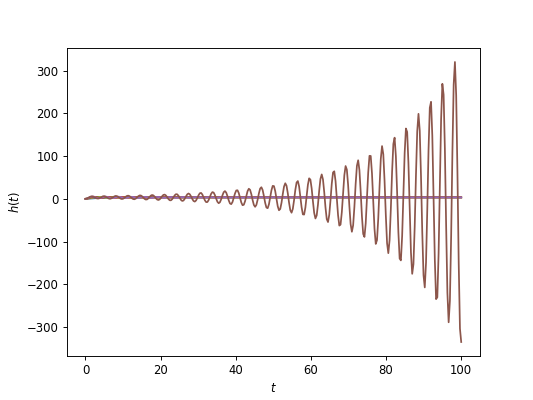

In [5]:
t = np.linspace(0, 100, 300)
_, x = control.step_response((1*hp).feedback(hf), T=t)
plt.plot(t, x)

_, x = control.step_response((3*hp).feedback(hf), T=t)
plt.plot(t, x)

_, x = control.step_response((5*hp).feedback(hf), T=t)
plt.plot(t, x)

_, x = control.step_response((7*hp).feedback(hf), T=t)
plt.plot(t, x)

_, x = control.step_response((9*hp).feedback(hf), T=t)
plt.plot(t, x)

_, x = control.step_response((11*hp).feedback(hf), T=t)
plt.plot(t, x)

plt.xlabel('$t$')
plt.ylabel('$h(t)$')
pass

In [ ]:
#11 уже подходит

<IPython.core.display.Javascript object>


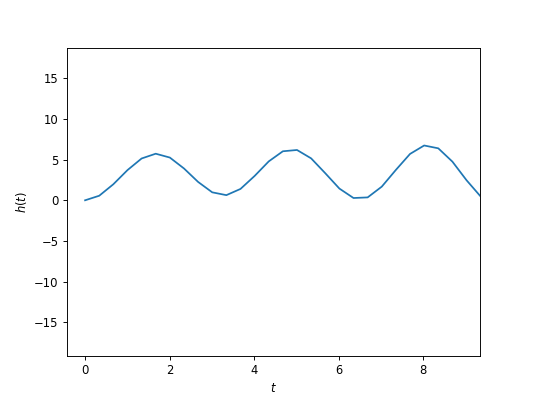

In [8]:
Ku=11

h = (pid(Ku)*hp).feedback(hf)

t, x = control.step_response(h, T=t)

plt.plot(t, x)
plt.xlabel('$t$')
plt.ylabel('$h(t)$')
pass

Период колебаний:  3.2042042042042045


<IPython.core.display.Javascript object>


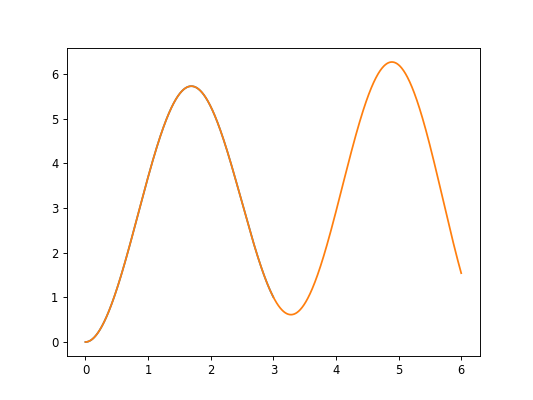

In [12]:
T1=np.linspace(0, 3, 1000)
_, x1 = control.step_response(h, T=T1)

T2=np.linspace(0, 6, 1000)
_, x2 = control.step_response(h, T=T2)

x1, x2 = list(x1), list(x2)

x1max = x1.index(max(x1))
x2max = x2.index(max(x2))

Tu=abs(T1[x1max]-T2[x2max])

print("Период колебаний: ", Tu)
plt.plot(T1, x1)
plt.plot(T2, x2)

In [13]:
def evolve(k, ti, td):
    
    print(f'Значения вычисляются для: ')
    print(f'{" "*25}K = {round(k/Ku, 1)} Ku')
    print(f'{" "*25}Ti = {str("1/") if ti!=0 else str("")}{round(Tu/ti, 1) if ti != 0 else 0} Tu')
    print(f'{" "*25}Td = {str("1/") if td!=0 else str("")}{round(Tu/td, 1) if td != 0 else 0} Tu')
    
    h3 = (pid(k, ti, td) * hp).feedback(hf)
    h0 =  control.margin((pid(k, ti, td) * hp) * hf)
    
    print(f'Запас по амплитуде равен {abs(20 * np.log10(h0[0]))} Дб или {h0[0]} раз\n')
    print(f'Запас по фазе {h0[1]} град.\n ')
    print(f'Перерегулирование {control.step_info(h3)["Overshoot"]*100} %\n ')

In [14]:
evolve(0.5*Ku, 0, 0)
print('-----------------------------------------')
evolve(0.45*Ku, 1/1.2*Tu, 0)
print('-----------------------------------------')
evolve(0.9*Ku, 0, 1/8*Tu)
print('-----------------------------------------')
evolve(0.6*Ku, 1/2*Tu, 1/8*Tu)
print('-----------------------------------------')
pass

Значения вычисляются для: 
                         K = 0.5 Ku
                         Ti = 0 Tu
                         Td = 0 Tu
Запас по амплитуде равен 5.06645048793202 Дб или 1.7919361232242388 раз

Запас по фазе 23.532604217852423 град.
 
Перерегулирование 3779.804882227664 %
 
-----------------------------------------
Значения вычисляются для: 
                         K = 0.5 Ku
                         Ti = 1/1.2 Tu
                         Td = 0 Tu
Запас по амплитуде равен inf Дб или inf раз

Запас по фазе 40.34672529181282 град.
 
Перерегулирование 1288.3335692722658 %
 
-----------------------------------------
Значения вычисляются для: 
                         K = 0.9 Ku
                         Ti = 0 Tu
                         Td = 1/8.0 Tu
Запас по амплитуде равен inf Дб или inf раз

Запас по фазе -62.13897353197906 град.
 
Перерегулирование 3821291.0461562607 %
 
-----------------------------------------
Значения вычисляются для: 
                         K = 0.6 